In [24]:
## Librerias ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
listings = pd.read_csv(
    "data/Listings.csv", encoding = "ISO-8859-1", 
    low_memory=False,
    parse_dates =["host_since"]
    )

In [5]:
## informacion general del csv listings.csv ##

listings.head()
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

In [6]:
## listings de la ciudad Paris con info de columnas especificas ##

paris_listings = (
    listings
    .query("city == 'Paris'")
    .loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]]
)
paris_listings.info()
paris_listings.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   neighbourhood  64690 non-null  object        
 2   city           64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867584,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [7]:
## creamos un dataframe de la ciudad de Paris por vecindario y precio ##

paris_listings_neighbourhood = (
    paris_listings
    .groupby("neighbourhood")
    .agg({"price": "mean"})
    .sort_values("price")
)
paris_listings_neighbourhood.head()
paris_listings_neighbourhood.tail()

,price
neighbourhood,
Luxembourg,155.638639
Palais-Bourbon,156.856578
Passy,161.144635
Louvre,175.379972
Elysee,210.536765


In [8]:
## Creamos un dataframe de la ciudad de Paris por acomodación y precio ## 

paris_listings_accommodates = (
    paris_listings
    .query("neighbourhood == 'Elysee'")
    .groupby("accommodates")
    .agg({"price": "mean"})
    .sort_values("price")
)
paris_listings_accommodates.head()
paris_listings_accommodates.tail()

,price
accommodates,
12,529.625
16,800.000
11,805.000
13,842.500
14,971.000


In [9]:
## Creamos un dataframe de la ciudad de Paris por temporalidad y precio ## 

paris_listings_over_time = (
    paris_listings
    .set_index("host_since")
    .resample("Y")
    .agg({
     "neighbourhood": "count",
     "price": "mean" 
    })
)
paris_listings_over_time.head()
#paris_listings_over_time.tail()

C:\Users\pablo\AppData\Local\Temp\ipykernel_2240\4264606873.py:6: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample("Y")


,neighbourhood,price
host_since,,
2008-12-31,4,77.750000
2009-12-31,106,159.641509
2010-12-31,416,125.031250
2011-12-31,1339,124.828230
2012-12-31,4592,111.578615


In [ ]:
### CREAMOS DIFERENTES GRAFICOS ### 

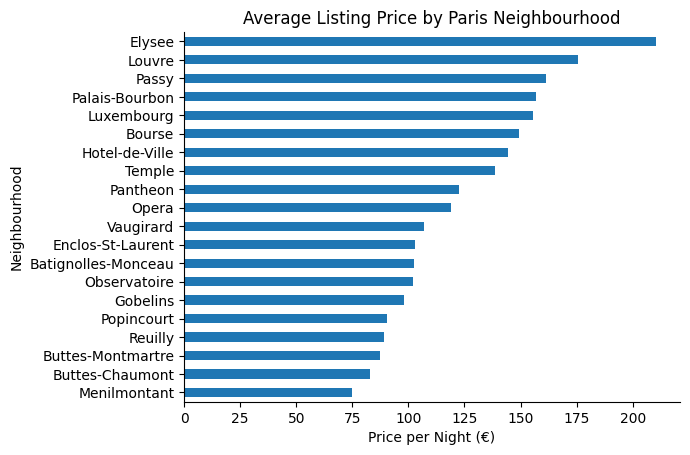

In [ ]:
(paris_listings_neighbourhood
 .plot
 .barh(
     title="Average Listing Price by Paris Neighbourhood",
     xlabel="Price per Night (€)",
     ylabel="Neighbourhood",
     legend=None 
     )
 )
sns.despine()

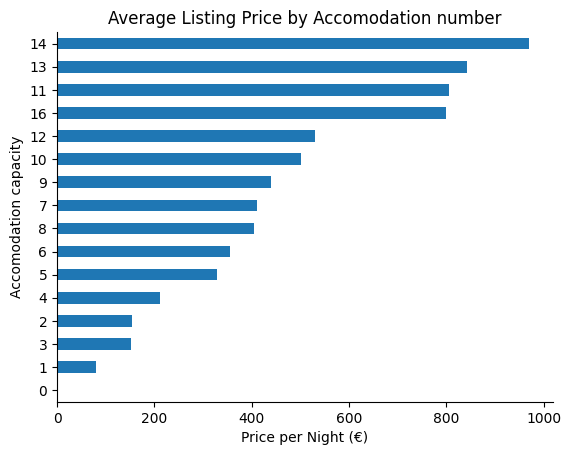

In [ ]:
(paris_listings_accommodates
 .plot
 .barh(
     title="Average Listing Price by Accomodation number",
     xlabel="Price per Night (€)",
     ylabel="Accomodation capacity",
     legend=None 
     )
 )
sns.despine()

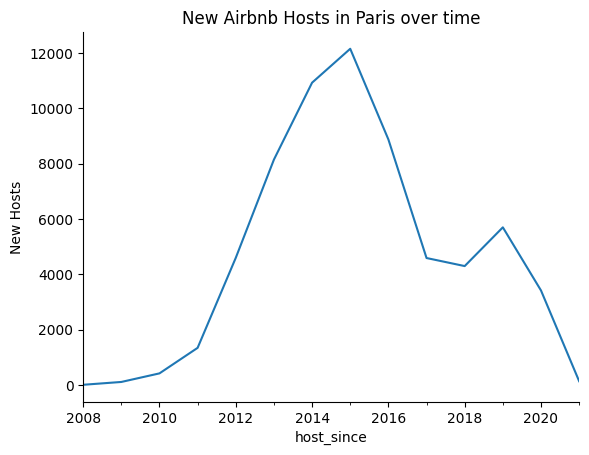

In [21]:
paris_listings_over_time["neighbourhood"].plot(
    ylabel="New Hosts",
    title="New Airbnb Hosts in Paris over time"
)

sns.despine()

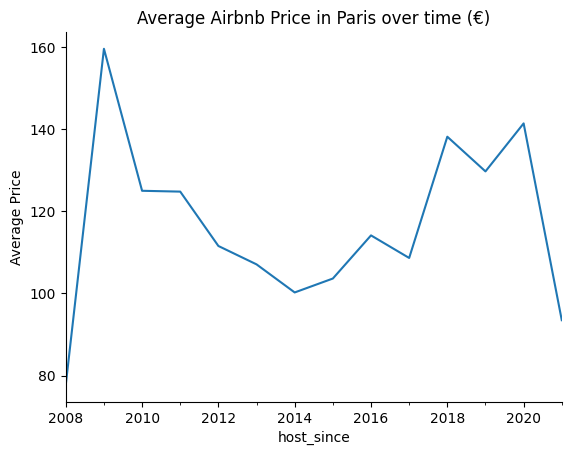

In [23]:
paris_listings_over_time["price"].plot(
    ylabel="Average Price",
    title="Average Airbnb Price in Paris over time (€)"
)

sns.despine()

Text(0.5, 1.0, '2015 regulations lead to fewer new hosts, higher prices')

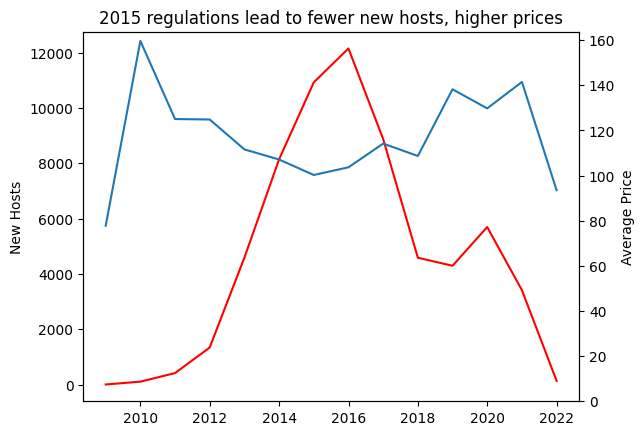

In [33]:
fig, ax=plt.subplots()

ax.plot(
    paris_listings_over_time.index,
    paris_listings_over_time["neighbourhood"],
    label="New Hosts",
    c="red"
)

ax.set_ylabel("New Hosts")

ax2=ax.twinx()
ax2.plot(
    paris_listings_over_time.index,
    paris_listings_over_time["price"],
    label="Average Price"
)
ax2.set_ylim(0)
ax2.set_ylabel("Average Price")
ax.set_title ("2015 regulations lead to fewer new hosts, higher prices")